# Day 08：分道扬镳 —— BERT 与 GPT，Transformer 的两条路> 🚀 第十二周 · 注意力时代 · 第 8 天Transformer 诞生后，很快分成了两条路线：- **BERT**（Encoder-only）：只保留 Encoder，擅长"理解"- **GPT**（Decoder-only）：只保留 Decoder，擅长"生成"这两条路线，塑造了今天 AI 的格局。**今天的任务**：1. 理解 BERT 和 GPT 的架构差异2. 用代码实现 BERT 的掩码语言模型3. 用代码实现 GPT 的自回归生成---

## 1. 历史剧场：2018-2019，两条路线的诞生**2018 年 10 月**：Google 发表 BERT（Bidirectional Encoder Representations from Transformers）- 只用 Transformer 的 Encoder- 双向注意力：每个词可以看到前后所有词- 预训练任务：掩码语言模型（完形填空）- 擅长：分类、问答、命名实体识别等"理解"任务**2018 年 6 月**（更早）：OpenAI 发表 GPT-1（Generative Pre-trained Transformer）- 只用 Transformer 的 Decoder- 单向注意力：每个词只能看到前面的词- 预训练任务：预测下一个词- 擅长：文本生成、对话、翻译等"生成"任务---

## 2. 生活隐喻：阅读理解 vs 作文- **BERT = 阅读理解**：给你一篇文章，让你填空、回答问题。你需要**理解**文章的每个部分- **GPT = 写作文**：给你一个开头，让你续写。你需要**生成**流畅的文字BERT 是"考官"——它看全文，理解含义GPT 是"作家"——它逐字写，追求流畅---

<p align="center">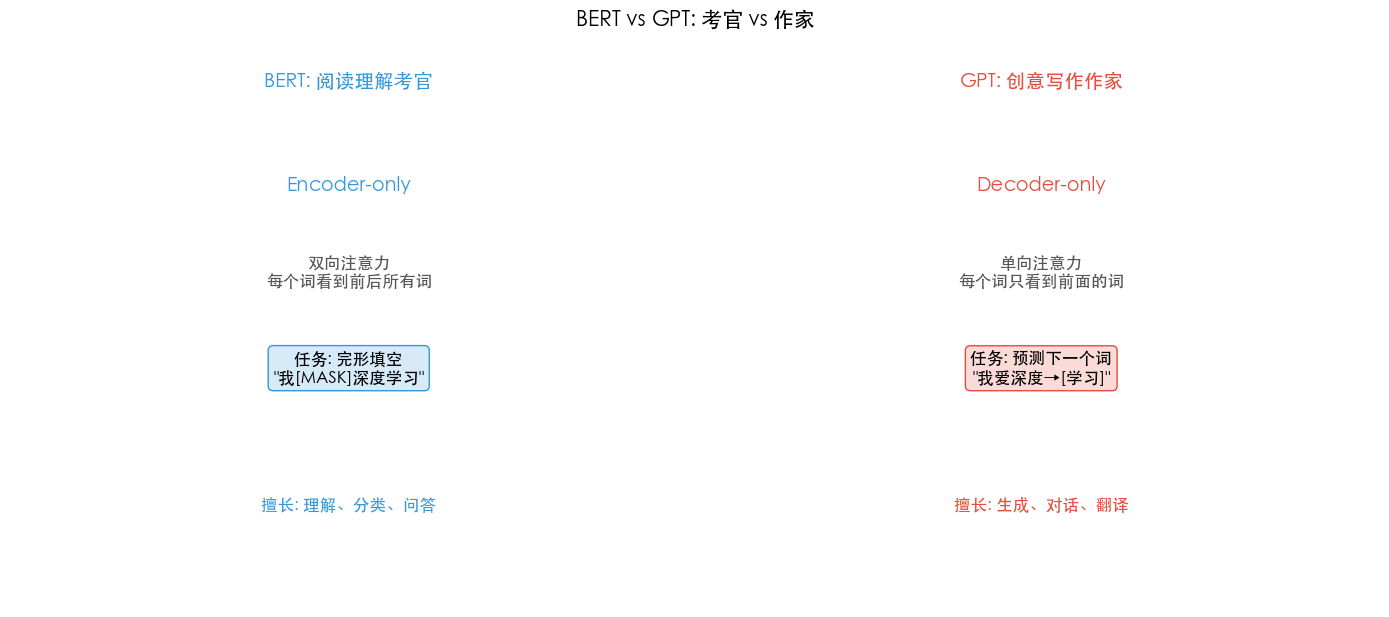</p>*BERT vs GPT 对比图*

## 3. 数学直觉：双向 vs 单向### 3.1 BERT 的双向注意力

输入: "我 [MASK] 深度学习"自注意力: "我" 可以看到 "[MASK]"、"深度"、"学习"          "[MASK]" 可以看到 "我"、"深度"、"学习"          → 双向！

BERT 的每个词都可以看到前后所有词，因此能获得完整的上下文。### 3.2 GPT 的单向注意力

输入: "我 爱 深度 学习"自注意力: "我" 只能看到 "我"          "爱" 只能看到 "我"、"爱"          "深度" 只能看到 "我"、"爱"、"深度"          → 单向！因果掩码！

GPT 的每个词只能看到自己和之前的词，保证了自回归生成的正确性。---

## 4. 代码实验室：BERT 掩码预测 vs GPT 逐词生成

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 简化版 BERT（掩码语言模型）

In [ ]:
class MiniBERT(nn.Module):    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=2):        super().__init__()        self.embedding = nn.Embedding(vocab_size, d_model)        self.pos_enc = PositionalEncoding(d_model)        encoder_layer = nn.TransformerEncoderLayer(            d_model, n_heads, d_model*4, batch_first=True, dropout=0.1)        self.encoder = nn.TransformerEncoder(encoder_layer, n_layers)        self.fc = nn.Linear(d_model, vocab_size)    def forward(self, x):        emb = self.pos_enc(self.embedding(x))        enc_out = self.encoder(emb)        logits = self.fc(enc_out)        return logitsclass PositionalEncoding(nn.Module):    def __init__(self, d_model, max_len=50):        super().__init__()        PE = torch.zeros(max_len, d_model)        pos = torch.arange(max_len).unsqueeze(1).float()        div = torch.exp(torch.arange(0, d_model, 2).float() *                       -(np.log(10000.0) / d_model))        PE[:, 0::2] = torch.sin(pos * div)        PE[:, 1::2] = torch.cos(pos * div)        self.register_buffer('PE', PE.unsqueeze(0))    def forward(self, x):        return x + self.PE[:, :x.size(1)]

### 4.2 BERT 训练：完形填空

In [ ]:
vocab = {'<PAD>': 0, '<MASK>': 1, '我': 2, '爱': 3, '喜欢': 4,         '深度': 5, '学习': 6, '机器': 7, '猫': 8, '狗': 9,         '音乐': 10, '编程': 11}vocab_size = len(vocab)sentences = [    [2, 3, 5, 6],    [2, 4, 8],    [2, 4, 9],    [2, 3, 7, 6],    [2, 4, 10],    [2, 4, 11],]bert = MiniBERT(vocab_size)optimizer = torch.optim.Adam(bert.parameters(), lr=0.01)loss_fn = nn.CrossEntropyLoss(ignore_index=0)bert_losses = []for epoch in range(200):    total_loss = 0    for sent in sentences:        sent_tensor = torch.tensor([sent])        mask_pos = np.random.randint(1, len(sent))        masked = sent.copy()        original = sent[mask_pos]        masked[mask_pos] = 1        masked_tensor = torch.tensor([masked])        logits = bert(masked_tensor)        target = torch.tensor([original])        loss = loss_fn(logits[0, mask_pos].unsqueeze(0), target)        optimizer.zero_grad()        loss.backward()        optimizer.step()        total_loss += loss.item()    bert_losses.append(total_loss / len(sentences))print("BERT 训练完成!")

### 4.3 简化版 GPT（自回归生成）

In [ ]:
class MiniGPT(nn.Module):    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=2):        super().__init__()        self.embedding = nn.Embedding(vocab_size, d_model)        self.pos_enc = PositionalEncoding(d_model)        decoder_layer = nn.TransformerDecoderLayer(            d_model, n_heads, d_model*4, batch_first=True, dropout=0.1)        self.decoder = nn.ModuleList([decoder_layer] * n_layers)        self.fc = nn.Linear(d_model, vocab_size)    def forward(self, x):        emb = self.pos_enc(self.embedding(x))        S = x.size(1)        mask = nn.Transformer.generate_square_subsequent_mask(S)        out = emb        enc_dummy = emb        for layer in self.decoder:            out = layer(out, enc_dummy, tgt_mask=mask)        return self.fc(out)gpt = MiniGPT(vocab_size)optimizer = torch.optim.Adam(gpt.parameters(), lr=0.01)gpt_losses = []for epoch in range(200):    total_loss = 0    for sent in sentences:        sent_tensor = torch.tensor([sent])        input_seq = sent_tensor[:, :-1]        target_seq = sent_tensor[:, 1:]        logits = gpt(input_seq)        loss = loss_fn(logits.reshape(-1, vocab_size), target_seq.reshape(-1))        optimizer.zero_grad()        loss.backward()        optimizer.step()        total_loss += loss.item()    gpt_losses.append(total_loss / len(sentences))print("GPT 训练完成!")

### 4.4 可视化对比

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].plot(bert_losses, color='#3498db', label='BERT (完形填空)', alpha=0.8)axes[0].plot(gpt_losses, color='#e74c3c', label='GPT (预测下一个词)', alpha=0.8)axes[0].set_xlabel('Epoch', fontsize=12)axes[0].set_ylabel('Loss', fontsize=12)axes[0].set_title('BERT vs GPT 训练损失', fontsize=14)axes[0].legend(fontsize=12)axes[0].grid(True, alpha=0.3)methods = ['BERT\n(Encoder-only)', 'GPT\n(Decoder-only)']features = {    '注意力方向': [2, 1],    '擅长任务': [1, 2],    '生成能力': [1, 2],    '理解能力': [2, 1],}x = np.arange(len(methods))width = 0.18colors = ['#3498db', '#e74c3c', '#27ae60', '#f39c12']for i, (feature, values) in enumerate(features.items()):    axes[1].bar(x + i*width, values, width, label=feature, color=colors[i], alpha=0.8)axes[1].set_xticks(x + width * 1.5)axes[1].set_xticklabels(methods, fontsize=11)axes[1].set_ylabel('能力评分 (1-2)', fontsize=12)axes[1].set_title('BERT vs GPT 能力对比', fontsize=14)axes[1].legend(fontsize=10)axes[1].grid(True, alpha=0.3, axis='y')plt.tight_layout()plt.show()

---

## 5. BERT vs GPT：全面对比| | BERT (Encoder-only) | GPT (Decoder-only) ||---|---|---|| 注意力方向 | 双向 | 单向（因果掩码） || 预训练任务 | 完形填空（掩码预测） | 预测下一个词 || 擅长 | 理解：分类、问答、NER | 生成：对话、翻译、创作 || 代表模型 | BERT, RoBERTa, ALBERT | GPT-3/4, LLaMA, ChatGPT || 输出 | 每个位置的表示 | 下一个词的概率 || 规模趋势 | 中等规模（~1B） | 超大规模（~1T） |**2023 年的趋势**：GPT 路线（Decoder-only）成为主流，因为"生成"是更通用的能力——能生成，就能理解；但能理解，不一定能生成。---

## 今日结语Transformer 分成了两条路线：- **BERT**（Encoder-only）：双向注意力，擅长理解，像考官- **GPT**（Decoder-only）：单向注意力，擅长生成，像作家两者各有优势，但 GPT 路线因为其"生成即通用"的特性，成为了大模型时代的主流。明天，我们将学习 Transformer 的训练技巧：学习率预热和标签平滑。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 阅读理解 vs 写作文 | BERT vs GPT || 考官——看全文理解含义 | Encoder-only——双向注意力 || 作家——逐字写追求流畅 | Decoder-only——单向注意力 || 完形填空 | 掩码语言模型——BERT 的预训练任务 || 续写故事 | 预测下一个词——GPT 的预训练任务 || 生成即通用 | GPT 路线成为主流的原因 |